In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("CrimeData").getOrCreate()
# Initialize Spark session
sc = spark.sparkContext

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/12 23:53:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Key Columns:

* **Crime ID**: A unique identifier for each crime.
* **Month**: The month in which the crime occurred (all data is from January 2023 to December 2024).
* **Reported by**: The police force that reported the crime (Derbyshire Constabulary, Leicestershire Police, or Nottinghamshire Police).
* **Longitude & Latitude**: The geographic coordinates where the crime occurred.
* **Location**: The specific location where the crime occurred.
* **LSOA Code and LSOA Name**: The statistical area the crime falls into.
* **Crime Type**: The category/type of crime (e.g., Anti-social behaviour, Theft, Drugs).
* **Last Outcome Category**: The status or outcome of the investigation (e.g., Offender given a caution, Investigation complete).


In [2]:
#use * to select all in the file
df = spark.read.csv("/kaggle/input/crimedataset/*/*.csv", header=True, inferSchema=True)

df.show()

+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+
|            Crime ID|              Month|         Reported by|        Falls within|Longitude| Latitude|            Location|LSOA code|        LSOA name|          Crime type|Last outcome category|Context|
+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+
|58047a3a95167140d...|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.347639|53.061766|On or near Regent...|E01019444|Amber Valley 003B|Violence and sexu...| Court result unav...|   NULL|
|8ac857a6be54f5424...|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.329102|53.024519|On or near Minkle...|E01019451|Amber Valley 012D|               Drugs| Unabl

In [3]:
df.printSchema()

root
 |-- Crime ID: string (nullable = true)
 |-- Month: timestamp (nullable = true)
 |-- Reported by: string (nullable = true)
 |-- Falls within: string (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- LSOA code: string (nullable = true)
 |-- LSOA name: string (nullable = true)
 |-- Crime type: string (nullable = true)
 |-- Last outcome category: string (nullable = true)
 |-- Context: string (nullable = true)



In [4]:
#renaming
df = df.withColumnRenamed('Crime ID', 'Crime_ID')
df = df.withColumnRenamed('Reported by', 'Reported_by') 
df = df.withColumnRenamed('Crime type', 'Crime_type') 
df = df.withColumnRenamed('Last outcome category', 'Last_outcome_category') 

df.printSchema()

root
 |-- Crime_ID: string (nullable = true)
 |-- Month: timestamp (nullable = true)
 |-- Reported_by: string (nullable = true)
 |-- Falls within: string (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- LSOA code: string (nullable = true)
 |-- LSOA name: string (nullable = true)
 |-- Crime_type: string (nullable = true)
 |-- Last_outcome_category: string (nullable = true)
 |-- Context: string (nullable = true)



In [5]:
#matching police names and counties through key pair value in RDDs
sc = spark.sparkContext 

countiesKey_rdd = sc.parallelize([
    ('Leicestershire Police', 'Leicestershire'),
    ('Derbyshire Constabulary', 'Derbyshire'),
    ('Nottinghamshire Police', 'Kent')
])

#change rdd into df
df_county = spark.createDataFrame(countiesKey_rdd, ["Reported_by", "County"]) 
#use reported by column 

#new df County
df_county.show() 


+--------------------+--------------+
|         Reported_by|        County|
+--------------------+--------------+
|Leicestershire Po...|Leicestershire|
|Derbyshire Consta...|    Derbyshire|
|Nottinghamshire P...|          Kent|
+--------------------+--------------+



In [6]:
#df = all 24 month data across the whole police forces
#df_mapped_crimes ,the DFrame that contains all the original crime data plus the new 'county' column

df_mapped_crimes = df.join(
    df_county, 
    on='Reported_by', # Match rows where police names are equal
    how='left'        # Use a left join to keep all original crime records
)


#checking if it joined through the report_by
df_mapped_crimes.show() 

+--------------------+--------------------+-------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+------+
|         Reported_by|            Crime_ID|              Month|        Falls within|Longitude| Latitude|            Location|LSOA code|        LSOA name|          Crime_type|Last_outcome_category|Context|County|
+--------------------+--------------------+-------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+------+
|Nottinghamshire P...|58047a3a95167140d...|2023-05-01 00:00:00|Nottinghamshire P...|-1.347639|53.061766|On or near Regent...|E01019444|Amber Valley 003B|Violence and sexu...| Court result unav...|   NULL|  Kent|
|Nottinghamshire P...|8ac857a6be54f5424...|2023-05-01 00:00:00|Nottinghamshire P...|-1.329102|53.024519|On or near Minkle...|E01019451|Amber Valley 012D

**TASK 2 USING SQL**

In [7]:
 #Created a new Temp SQL from df_mapped_crimes
df_mapped_crimes.createOrReplaceTempView("Crimes")

#calculates the total number of crimes for each county 23/24
#total frequency in DESC order
sql_advanced = spark.sql("""
 SELECT County, COUNT(*) AS Total 
 FROM Crimes
 GROUP BY County
 ORDER BY Total DESC
""")
sql_advanced.show()
# highest was Kent and lowest Leicestershire across 23/24.

+--------------+------+
|        County| Total|
+--------------+------+
|          Kent|258417|
|    Derbyshire|219339|
|Leicestershire|217944|
+--------------+------+



In [8]:
#crimes per year and month for each county highest lowest based on county
freq_of_crimes =spark.sql("""

SELECT substring(Month, 1, 7) as Year, COUNT(*) as Crime_Count, County
FROM Crimes
GROUP BY County,Month
ORDER BY Month ASC
""")

freq_of_crimes.show()
#showing 20 rows 

+-------+-----------+--------------+
|   Year|Crime_Count|        County|
+-------+-----------+--------------+
|2023-01|      10665|          Kent|
|2023-01|       8676|Leicestershire|
|2023-01|       8884|    Derbyshire|
|2023-02|       9156|    Derbyshire|
|2023-02|       8793|Leicestershire|
|2023-02|      10889|          Kent|
|2023-03|       9982|    Derbyshire|
|2023-03|       9591|Leicestershire|
|2023-03|      11640|          Kent|
|2023-04|       9595|Leicestershire|
|2023-04|      10151|    Derbyshire|
|2023-04|      11737|          Kent|
|2023-05|      12471|          Kent|
|2023-05|       9835|Leicestershire|
|2023-05|      10744|    Derbyshire|
|2023-06|      10423|    Derbyshire|
|2023-06|      12346|          Kent|
|2023-06|       9760|Leicestershire|
|2023-07|       9221|Leicestershire|
|2023-07|      10152|    Derbyshire|
+-------+-----------+--------------+
only showing top 20 rows



In [9]:
#most common and least common crime types in each county
#using crime_type
# most common crime type in each county
# using crime_type
common_crimes = spark.sql("""
SELECT County ,Crime_type, COUNT(*) as Common_Crime_Count 
FROM Crimes
GROUP BY County, Crime_type
""")

common_crimes.show()
# shows top crime type per county



+--------------+--------------------+------------------+
|        County|          Crime_type|Common_Crime_Count|
+--------------+--------------------+------------------+
|          Kent|Possession of wea...|              3205|
|    Derbyshire|Theft from the pe...|              1265|
|    Derbyshire|        Public order|             21519|
|    Derbyshire|         Other crime|              4335|
|    Derbyshire|             Robbery|              1341|
|Leicestershire|               Drugs|              6467|
|          Kent|            Burglary|              8598|
|          Kent|        Public order|             15982|
|          Kent|               Drugs|              7969|
|          Kent|             Robbery|              2173|
|    Derbyshire|Criminal damage a...|             16416|
|          Kent|         Other theft|             16675|
|    Derbyshire|               Drugs|              5411|
|          Kent|       Bicycle theft|              2430|
|    Derbyshire|       Vehicle 

**TASK 3 Visualisation**

* must often be converted into a Pandas, .toPandas() 
* one line graph three counties using different colours or styles
* one bar chart, total number of each crime type across the two years for each county
* three pie charts, per county  crime types 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

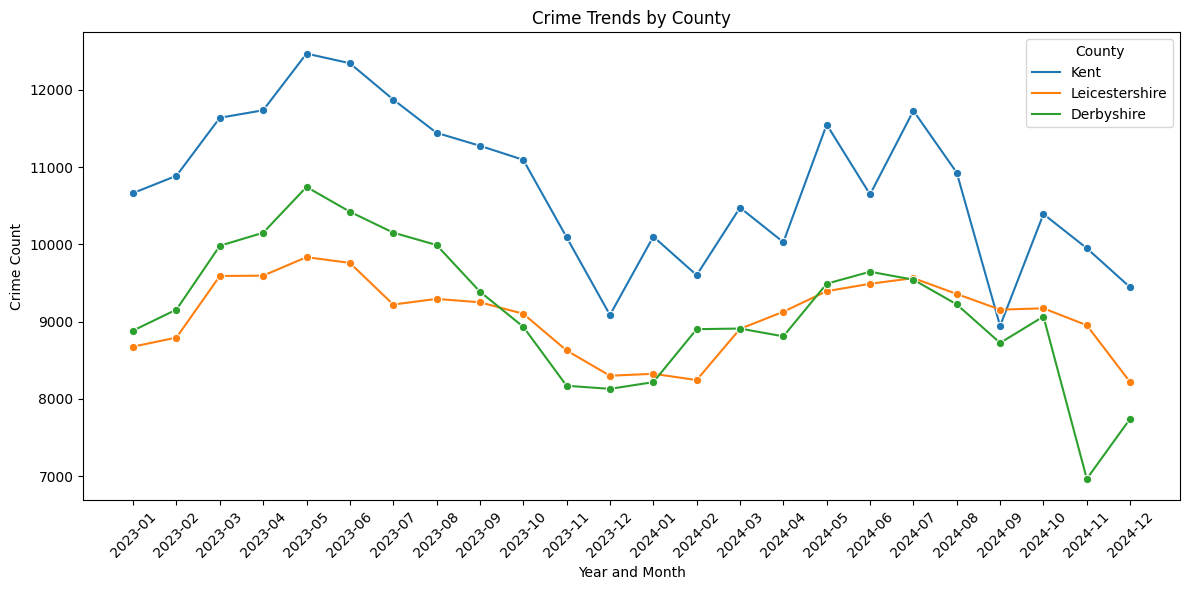

In [10]:
# Conversion to Pandas DataFrame for visualization
freq_of_crimes_pd = freq_of_crimes.toPandas()

#imports libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Visual Representation Line Graph
plt.figure(figsize=(12,6))

sns.lineplot(data=freq_of_crimes_pd, x='Year', y='Crime_Count', hue='County', marker='o')

#title, x/y axis names
plt.title("Crime Trends by County")
plt.xlabel("Year and Month")
plt.ylabel("Crime Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

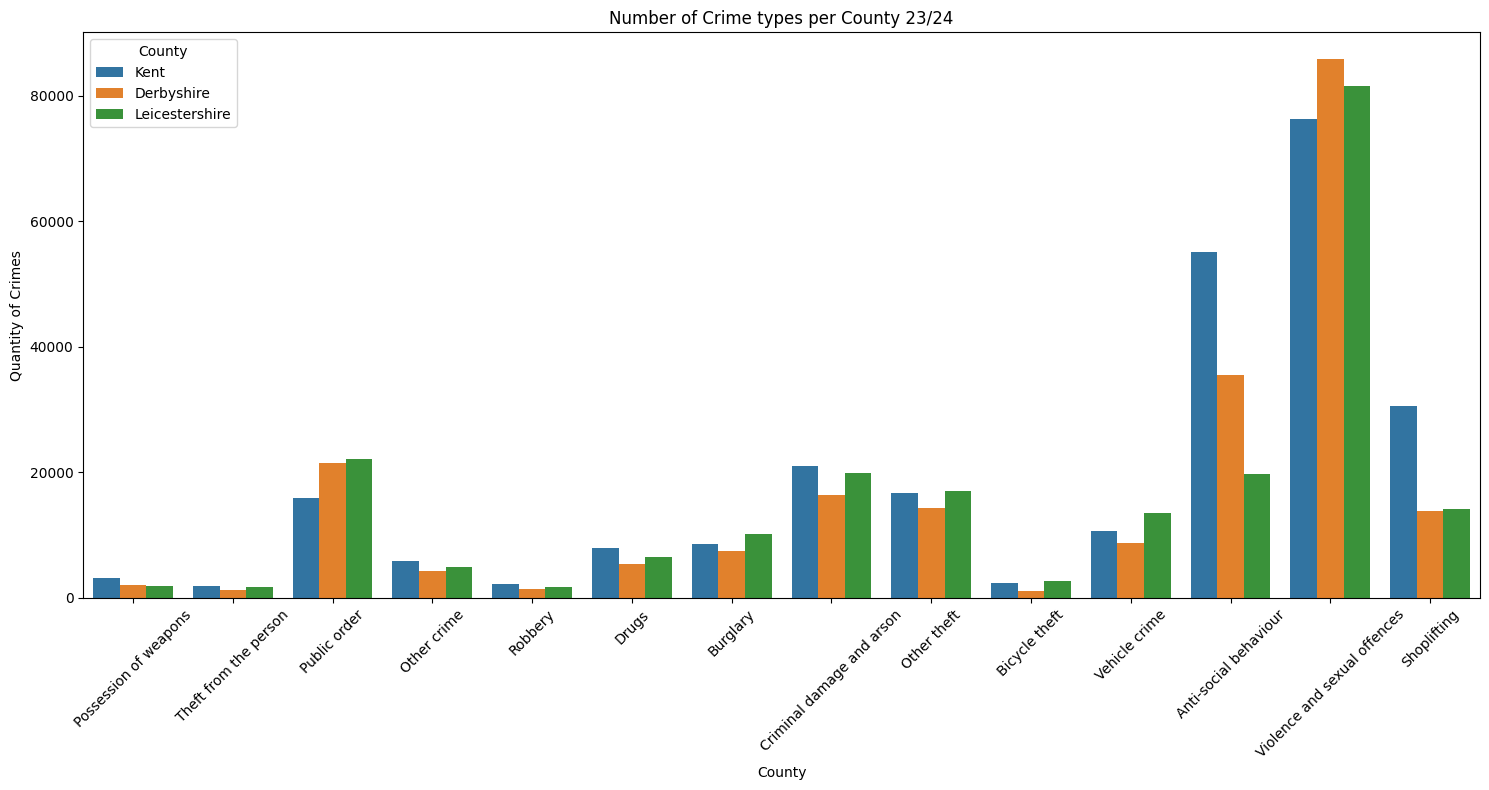

In [11]:
#Bar chart showing number of crimes per county 
common_crimes_pd =common_crimes.toPandas()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

# Create a bar plot
sns.barplot(data=common_crimes_pd, x='Crime_type', y='Common_Crime_Count', hue='County')




# Add labels and title
plt.title('Number of Crime types per County 23/24')
plt.xlabel('County')
plt.ylabel('Quantity of Crimes')


plt.xticks(rotation=45)
plt.tight_layout()
# Show the plot

plt.show()


In [12]:
derby_crime_type = spark.sql(""" 
SELECT COUNTY ,CRIME_TYPE, COUNT(*) as Crime_Count 
FROM Crimes
WHERE County= 'Derbyshire'
GROUP BY County, CRIME_TYPE
ORDER BY County, Crime_Count DESC
""")

derby_crime_type.show()

+----------+--------------------+-----------+
|    COUNTY|          CRIME_TYPE|Crime_Count|
+----------+--------------------+-----------+
|Derbyshire|Violence and sexu...|      85816|
|Derbyshire|Anti-social behav...|      35537|
|Derbyshire|        Public order|      21519|
|Derbyshire|Criminal damage a...|      16416|
|Derbyshire|         Other theft|      14375|
|Derbyshire|         Shoplifting|      13826|
|Derbyshire|       Vehicle crime|       8795|
|Derbyshire|            Burglary|       7541|
|Derbyshire|               Drugs|       5411|
|Derbyshire|         Other crime|       4335|
|Derbyshire|Possession of wea...|       2010|
|Derbyshire|             Robbery|       1341|
|Derbyshire|Theft from the pe...|       1265|
|Derbyshire|       Bicycle theft|       1152|
+----------+--------------------+-----------+



In [13]:
kent_crime_type = spark.sql(""" 
SELECT COUNTY ,CRIME_TYPE, COUNT(*) as Crime_Count 
FROM Crimes
WHERE County= 'Kent'
GROUP BY County, CRIME_TYPE
ORDER BY County, Crime_Count DESC
""")

kent_crime_type.show()

+------+--------------------+-----------+
|COUNTY|          CRIME_TYPE|Crime_Count|
+------+--------------------+-----------+
|  Kent|Violence and sexu...|      76255|
|  Kent|Anti-social behav...|      55060|
|  Kent|         Shoplifting|      30524|
|  Kent|Criminal damage a...|      20980|
|  Kent|         Other theft|      16675|
|  Kent|        Public order|      15982|
|  Kent|       Vehicle crime|      10717|
|  Kent|            Burglary|       8598|
|  Kent|               Drugs|       7969|
|  Kent|         Other crime|       5947|
|  Kent|Possession of wea...|       3205|
|  Kent|       Bicycle theft|       2430|
|  Kent|             Robbery|       2173|
|  Kent|Theft from the pe...|       1902|
+------+--------------------+-----------+



In [14]:
lei_crime_type = spark.sql(""" 
SELECT COUNTY ,CRIME_TYPE, COUNT(*) as Crime_Count 
FROM Crimes
WHERE County= 'Leicestershire'
GROUP BY County, CRIME_TYPE
ORDER BY County, Crime_Count DESC
""")

lei_crime_type.show()

+--------------+--------------------+-----------+
|        COUNTY|          CRIME_TYPE|Crime_Count|
+--------------+--------------------+-----------+
|Leicestershire|Violence and sexu...|      81604|
|Leicestershire|        Public order|      22136|
|Leicestershire|Criminal damage a...|      19969|
|Leicestershire|Anti-social behav...|      19678|
|Leicestershire|         Other theft|      16991|
|Leicestershire|         Shoplifting|      14201|
|Leicestershire|       Vehicle crime|      13584|
|Leicestershire|            Burglary|      10225|
|Leicestershire|               Drugs|       6467|
|Leicestershire|         Other crime|       4889|
|Leicestershire|       Bicycle theft|       2734|
|Leicestershire|Possession of wea...|       1967|
|Leicestershire|Theft from the pe...|       1764|
|Leicestershire|             Robbery|       1735|
+--------------+--------------------+-----------+



/tmp/ipykernel_13/3643287730.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors=plt.cm.get_cmap('tab20', len(derby_crime_type_pd))(range(len(derby_crime_type_pd)))


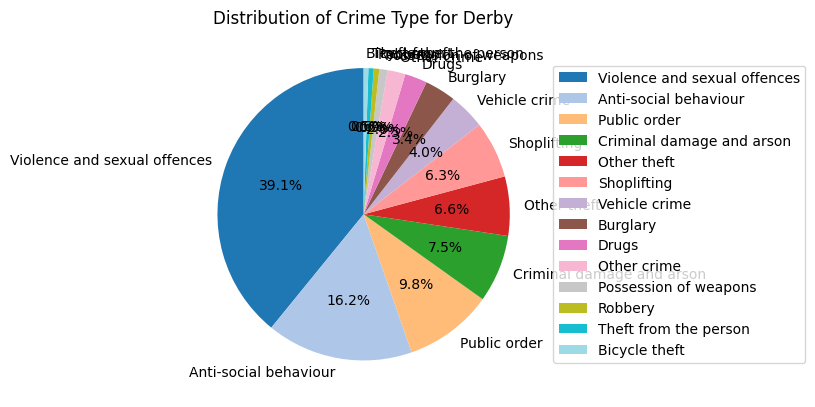

In [15]:
#Derby Pie chart from crime type
derby_crime_type_pd = derby_crime_type.toPandas()


fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    derby_crime_type_pd['Crime_Count'], 
    labels= derby_crime_type_pd['CRIME_TYPE'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=plt.cm.get_cmap('tab20', len(derby_crime_type_pd))(range(len(derby_crime_type_pd)))
)

plt.legend(
    derby_crime_type_pd['CRIME_TYPE'], 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.title("Distribution of Crime Type for Derby")
plt.show()



/tmp/ipykernel_13/3479078017.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors=plt.cm.get_cmap('tab20', len(kent_crime_type_pd))(range(len(kent_crime_type_pd)))


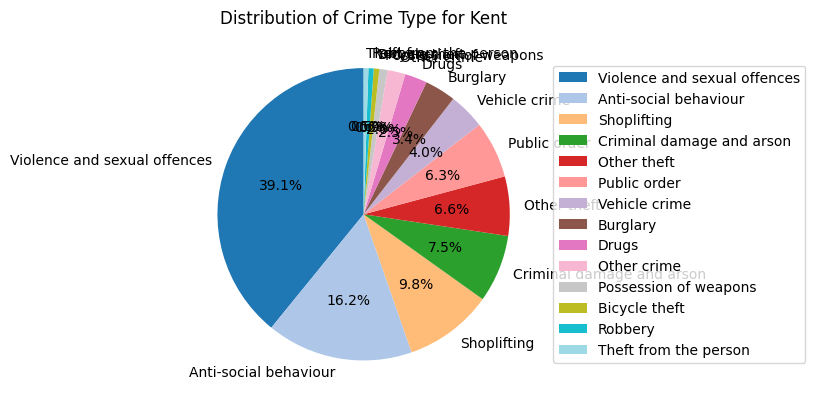

In [16]:
#Kent Pie chart from crime type
kent_crime_type_pd = kent_crime_type.toPandas()


fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    derby_crime_type_pd['Crime_Count'], 
    labels= kent_crime_type_pd['CRIME_TYPE'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=plt.cm.get_cmap('tab20', len(kent_crime_type_pd))(range(len(kent_crime_type_pd)))
)

plt.legend(
    kent_crime_type_pd['CRIME_TYPE'], 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.title("Distribution of Crime Type for Kent")
plt.show()


/tmp/ipykernel_13/3640073923.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors=plt.cm.get_cmap('tab20', len(lei_crime_type_pd))(range(len(lei_crime_type_pd)))


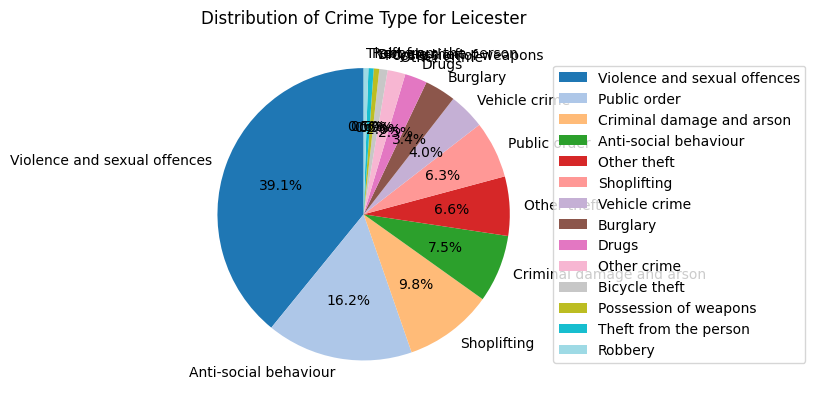

In [17]:
#Leicester Pie chart from crime type
lei_crime_type_pd = lei_crime_type.toPandas()


fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    derby_crime_type_pd['Crime_Count'], 
    labels= kent_crime_type_pd['CRIME_TYPE'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=plt.cm.get_cmap('tab20', len(lei_crime_type_pd))(range(len(lei_crime_type_pd)))
)

plt.legend(
    lei_crime_type_pd['CRIME_TYPE'], 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.title("Distribution of Crime Type for Leicester")
plt.show()



#need to space the labels


Summary of analysis
Highest is Derby


Most common is 'Violence and sexual offences' for all 3


Drop in crimes for all 3 counties 
2023 Oct-Dec

